<a href="https://colab.research.google.com/github/YOKI2005792/Election_Outcome_Prediction.ipynb/blob/main/Election_Outcome_Prediction_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
data = pd.read_csv('/content/eletion result.csv')
data = data.drop(['Code','Last Updated Time','Last Updated Date'],axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4257 entries, 0 to 4256
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Constituency  4257 non-null   object 
 1   Candidate     4257 non-null   object 
 2   Party         4257 non-null   object 
 3   EVM Votes     4257 non-null   int64  
 4   Postal Votes  4257 non-null   int64  
 5   Total Votes   4257 non-null   int64  
 6   % Votes       4257 non-null   float64
 7   Round         4257 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 266.2+ KB


In [ ]:
data['Winner'] = (
    data.groupby('Constituency')['Total Votes']
    .transform('max') == data['Total Votes']
).astype(int)
data.info()
X = data.drop('Winner', axis=1)
y = data['Winner']




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4257 entries, 0 to 4256
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Constituency  4257 non-null   object 
 1   Candidate     4257 non-null   object 
 2   Party         4257 non-null   object 
 3   EVM Votes     4257 non-null   int64  
 4   Postal Votes  4257 non-null   int64  
 5   Total Votes   4257 non-null   int64  
 6   % Votes       4257 non-null   float64
 7   Round         4257 non-null   object 
 8   Winner        4257 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 299.4+ KB


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'Constituency',
    'Candidate',
    'Party',
    'Round'
]

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X_scaled,y,test_size =0.2,random_state = 42)
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train, Y_train = sm.fit_resample(x_train, y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train,Y_train)
PRED =model.predict(x_test)


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, PRED))

Accuracy: 0.9753521126760564


In [ ]:
candidate_names = data['Candidate']
results = pd.DataFrame({
    'Candidate': candidate_names.iloc[y_test.index],
    'Prediction': PRED
})

winners = results[results['Prediction'] == 1]
len(winners)

In [ ]:
candidate_names = data['Candidate']
results = pd.DataFrame({
    'Candidate': data.loc[y_test.index, 'Candidate'],
    'Constituency': data.loc[y_test.index, 'Constituency'],
    'Party': data.loc[y_test.index, 'Party'],
    'Votes': data.loc[y_test.index, 'Total Votes'],
    'Prediction': PRED
})
winners = results[results['Prediction'] == 1]
print(winners.reset_index(drop=True))

                  Candidate                 Constituency  \
0        MADHAR BADHURUDEEN        MADURAI CENTRAL - 193   
1                    RAMESH              SRIRANGAM - 139   
2           RAJENDRAN. T. M           KADAYANALLUR - 221   
3       KALAIVANAN POONDI K             THIRUVARUR - 168   
4                   M. RAJU                COONOOR - 110   
5            RAMACHANDRAN.S            KILPENNATHUR - 64   
6           MARKANDAYAN G V           VILATHIKULAM - 213   
7         THARAHAI CUTHBERT               COLACHAL - 231   
8             ASHOK KUMAR G           RISHIVANDIYAM - 78   
9           M.L.VIJAYPRABHU                MADAVARAM - 9   
10            AADHAV ARJUNA             VILLIVAKKAM - 14   
11                 M.HARISH                 ALANDUR - 28   
12       R JAYARAMAKRISHNAN           MADATHUKULAM - 126   
13          KARUPPANAN. K.C                BHAVANI - 104   
14                  RANI. P               VANDAVASI - 69   
15             V. GANDHIRAJ             

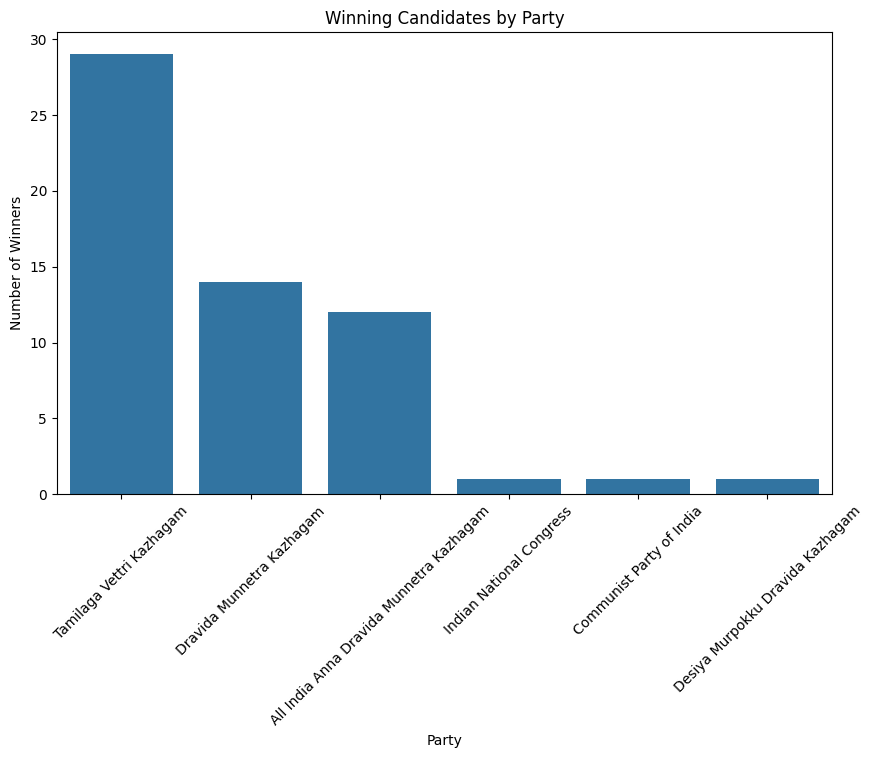

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))

sns.countplot(
    x='Party',
    data=winners
)

plt.title("Winning Candidates by Party")

plt.xlabel("Party")
plt.ylabel("Number of Winners")

plt.xticks(rotation=45)

plt.show()

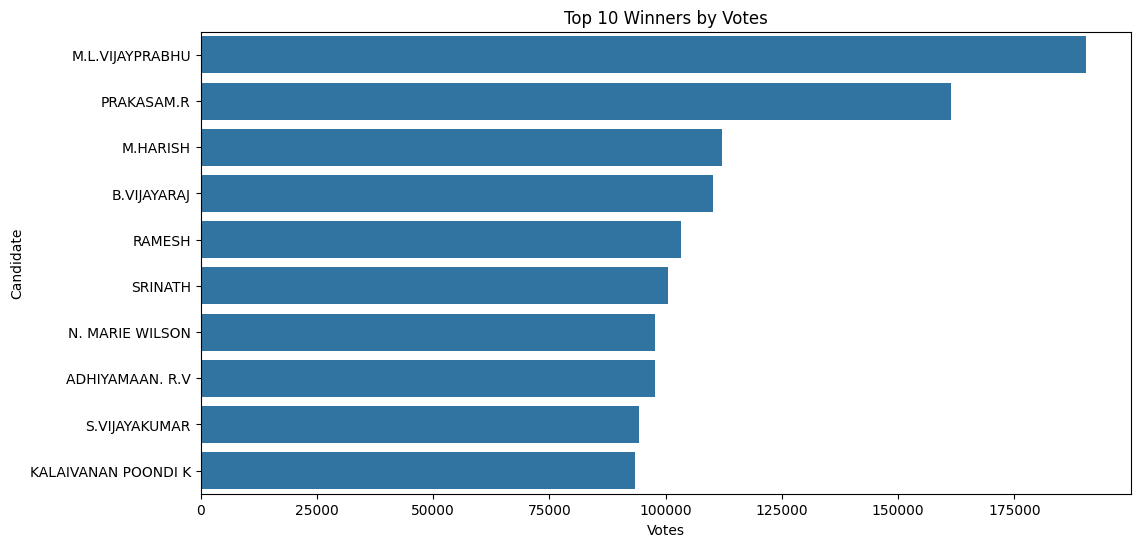

In [ ]:
top10 = winners.sort_values(
    by='Votes',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x='Votes',
    y='Candidate',
    data=top10
)

plt.title("Top 10 Winners by Votes")

plt.xlabel("Votes")
plt.ylabel("Candidate")

plt.show()

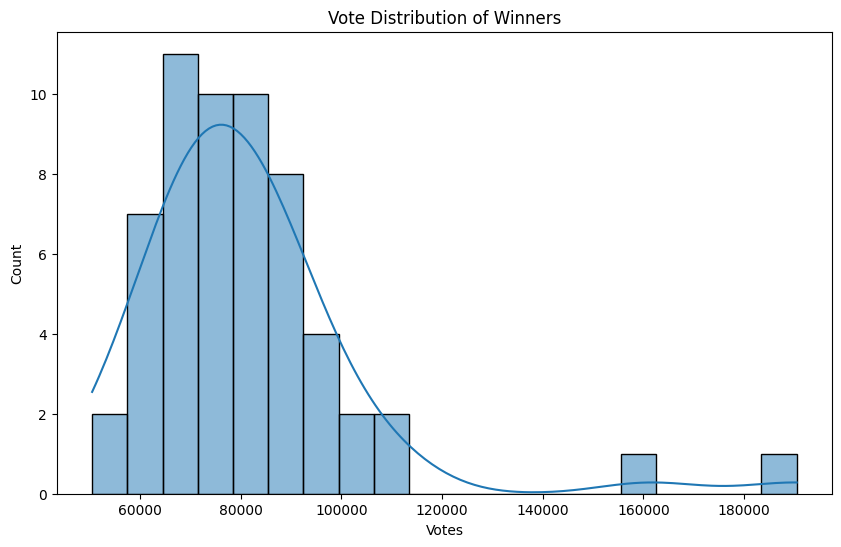

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    winners['Votes'],
    bins=20,
    kde=True
)

plt.title("Vote Distribution of Winners")

plt.xlabel("Votes")

plt.show()


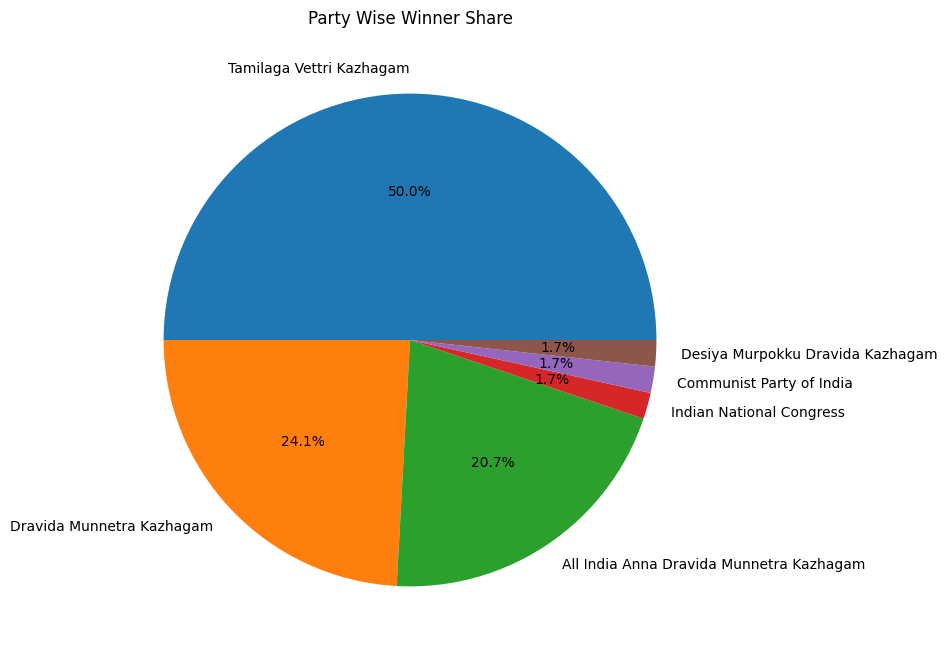

In [ ]:
party_count = winners['Party'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    party_count,
    labels=party_count.index,
    autopct='%1.1f%%'
)

plt.title("Party Wise Winner Share")

plt.show()

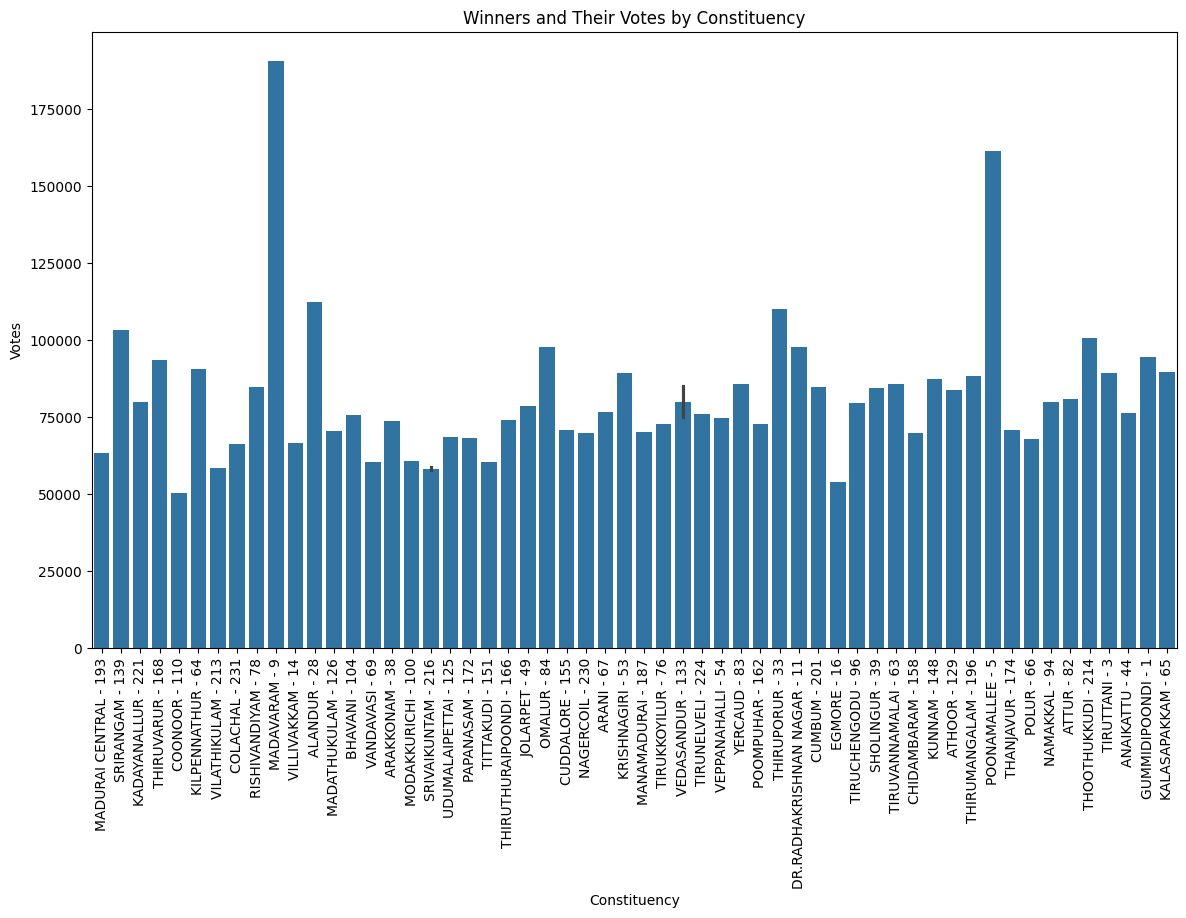

In [ ]:
plt.figure(figsize=(14,8))

sns.barplot(
    x='Constituency',
    y='Votes',
    data=winners
)

plt.title("Winners and Their Votes by Constituency")

plt.xlabel("Constituency")
plt.ylabel("Votes")

plt.xticks(rotation=90)

plt.show()